# Assignment2 - Supervised Learning flow

# Part 1 - Student details:

In [224]:
# student 1: Yuval Cohen

## Part 2 - Initial Preparations 

In [225]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=SettingWithCopyWarning)

In [226]:
# Load the data
train_df = pd.read_csv("housing_train.csv")
test_df = pd.read_csv("housing_test.csv")

In [227]:
# Basic inspection of data
print("Train Data Info:")
train_df.info()
print("\nTest Data Info:")
test_df.info()

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       16512 non-null  float64
 1   HouseAge     16512 non-null  float64
 2   AveRooms     16512 non-null  float64
 3   AveBedrms    16512 non-null  float64
 4   Population   16512 non-null  float64
 5   AveOccup     16512 non-null  float64
 6   Latitude     16512 non-null  float64
 7   Longitude    16512 non-null  float64
 8   MedHouseVal  16512 non-null  float64
dtypes: float64(9)
memory usage: 1.1 MB

Test Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       4128 non-null   float64
 1   HouseAge     4128 non-null   float64
 2   AveRooms     4128 non-null   float64
 3   AveBedrms    4128 non-null   float6

In [228]:
train_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.863517,28.650678,5.412479,1.093546,1424.287609,3.101201,35.631452,-119.566283,2.065267
std,1.878577,12.623994,2.088680,0.378594,1139.012630,11.587773,2.137537,2.006552,1.151219
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.564375,18.000000,4.448665,1.005988,789.000000,2.431070,33.930000,-121.800000,1.192000
50%,3.536650,29.000000,5.225511,1.048780,1167.000000,2.816355,34.250000,-118.490000,1.796000
75%,4.744375,37.000000,6.046629,1.099691,1722.000000,3.281612,37.710000,-118.000000,2.647000
max,15.000100,52.000000,62.422222,15.312500,35682.000000,1243.333333,41.950000,-114.310000,5.000010


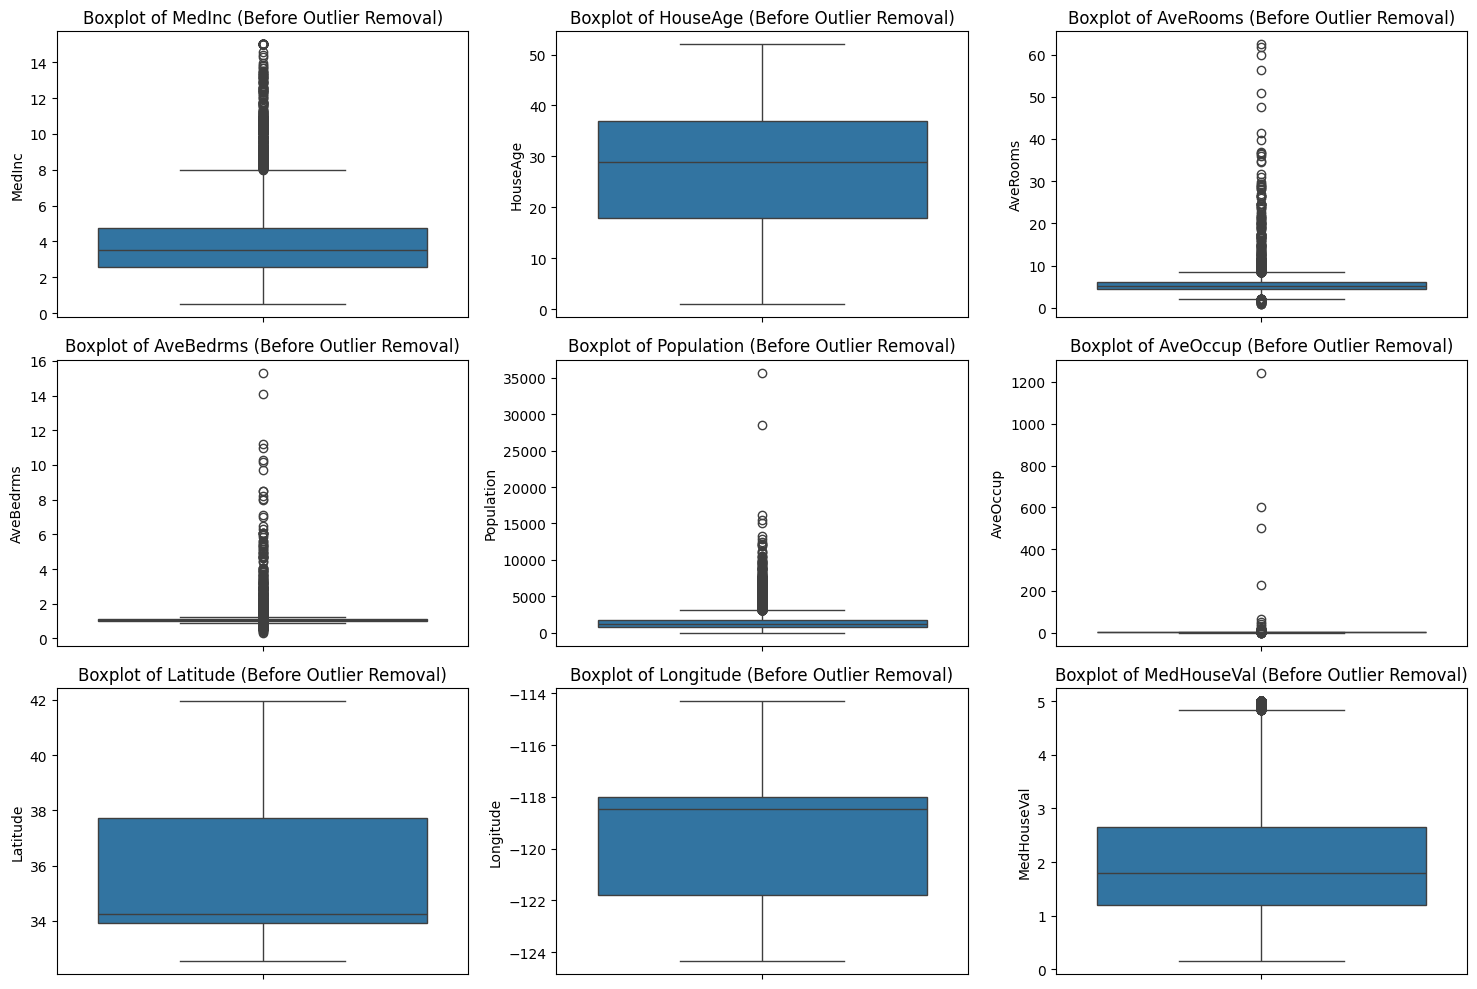

In [229]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(train_df.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(train_df[column])
    plt.title(f'Boxplot of {column} (Before Outlier Removal)')
plt.tight_layout()
plt.show()

In [230]:
# Handle Outliers using IQR method
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = train_df.quantile(0.25)
Q3 = train_df.quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers from the training data
train_df_no_outliers = train_df[~((train_df < lower_bound) | (train_df > upper_bound)).any(axis=1)]

Original data shape: (16512, 9)
Data shape after removing outliers: (13058, 9)


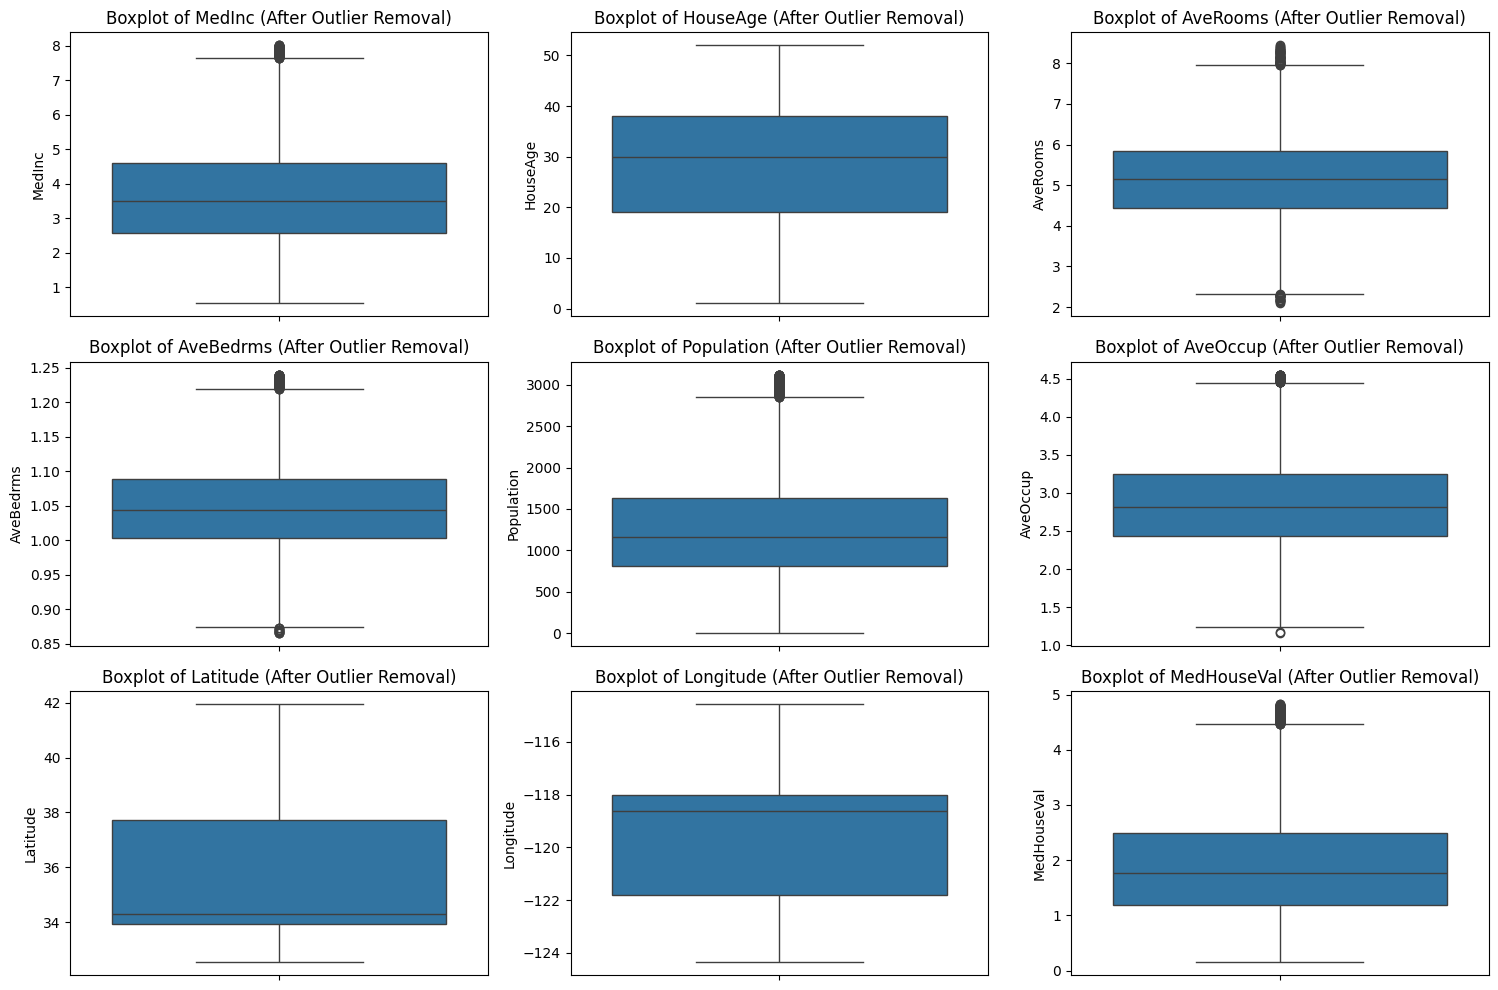

In [231]:
# Check the shape difference before and after removing outliers
print(f"Original data shape: {train_df.shape}")
print(f"Data shape after removing outliers: {train_df_no_outliers.shape}")

plt.figure(figsize=(15, 10))
for i, column in enumerate(train_df_no_outliers.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(train_df_no_outliers[column])
    plt.title(f'Boxplot of {column} (After Outlier Removal)')
plt.tight_layout()
plt.show()

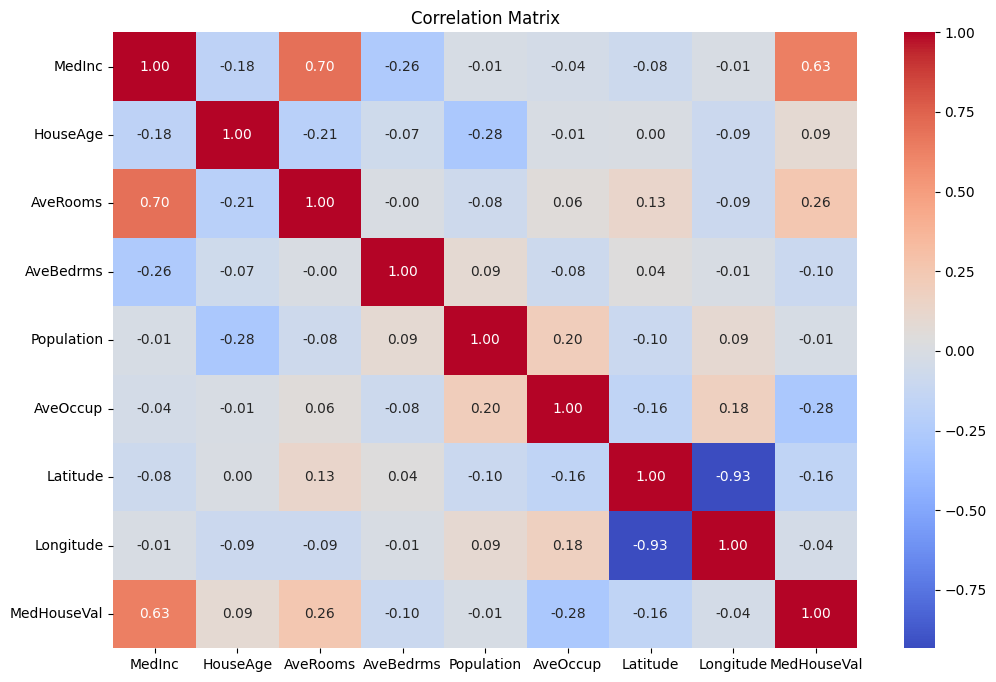

In [232]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = train_df_no_outliers.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

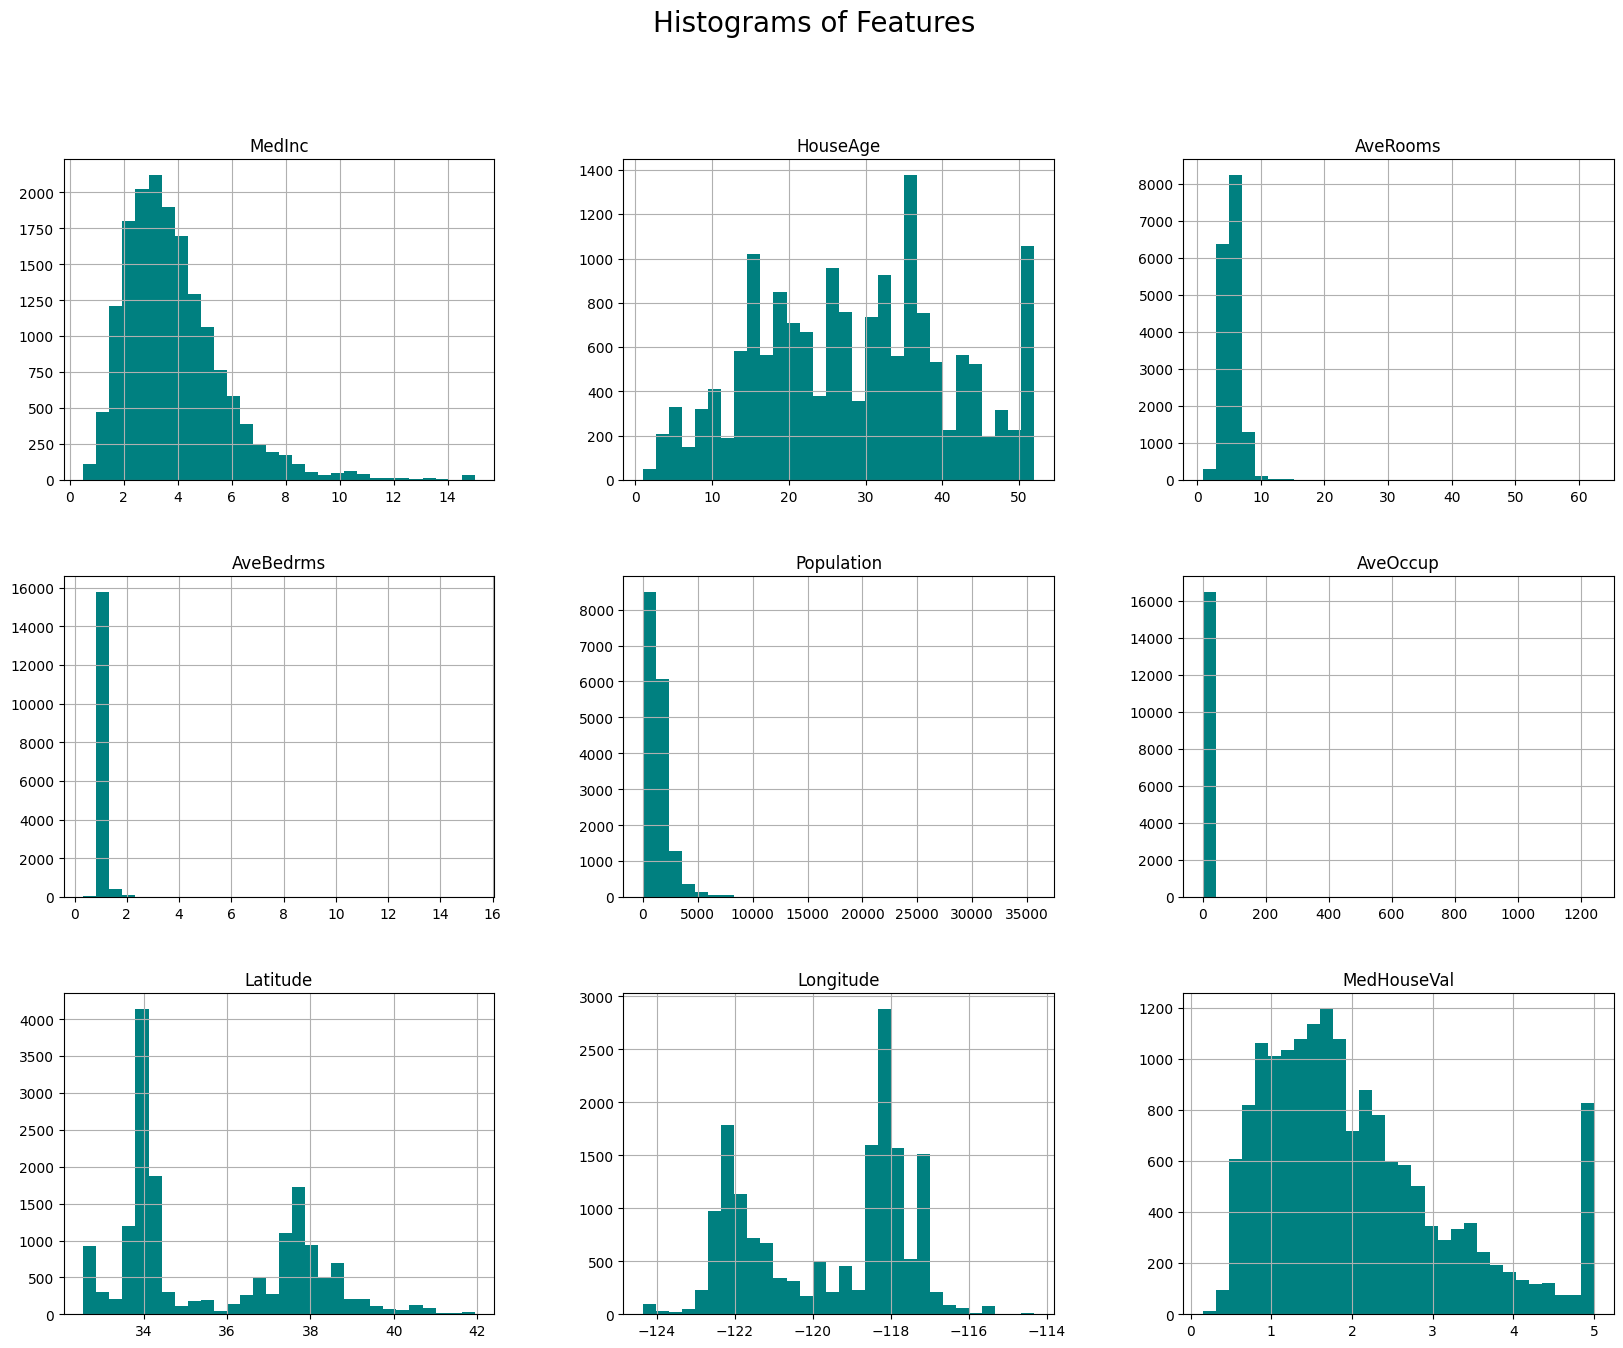

In [233]:
train_df.hist(bins=30, figsize=(20, 15), color='teal')
plt.suptitle('Histograms of Features', size=20)
plt.show()

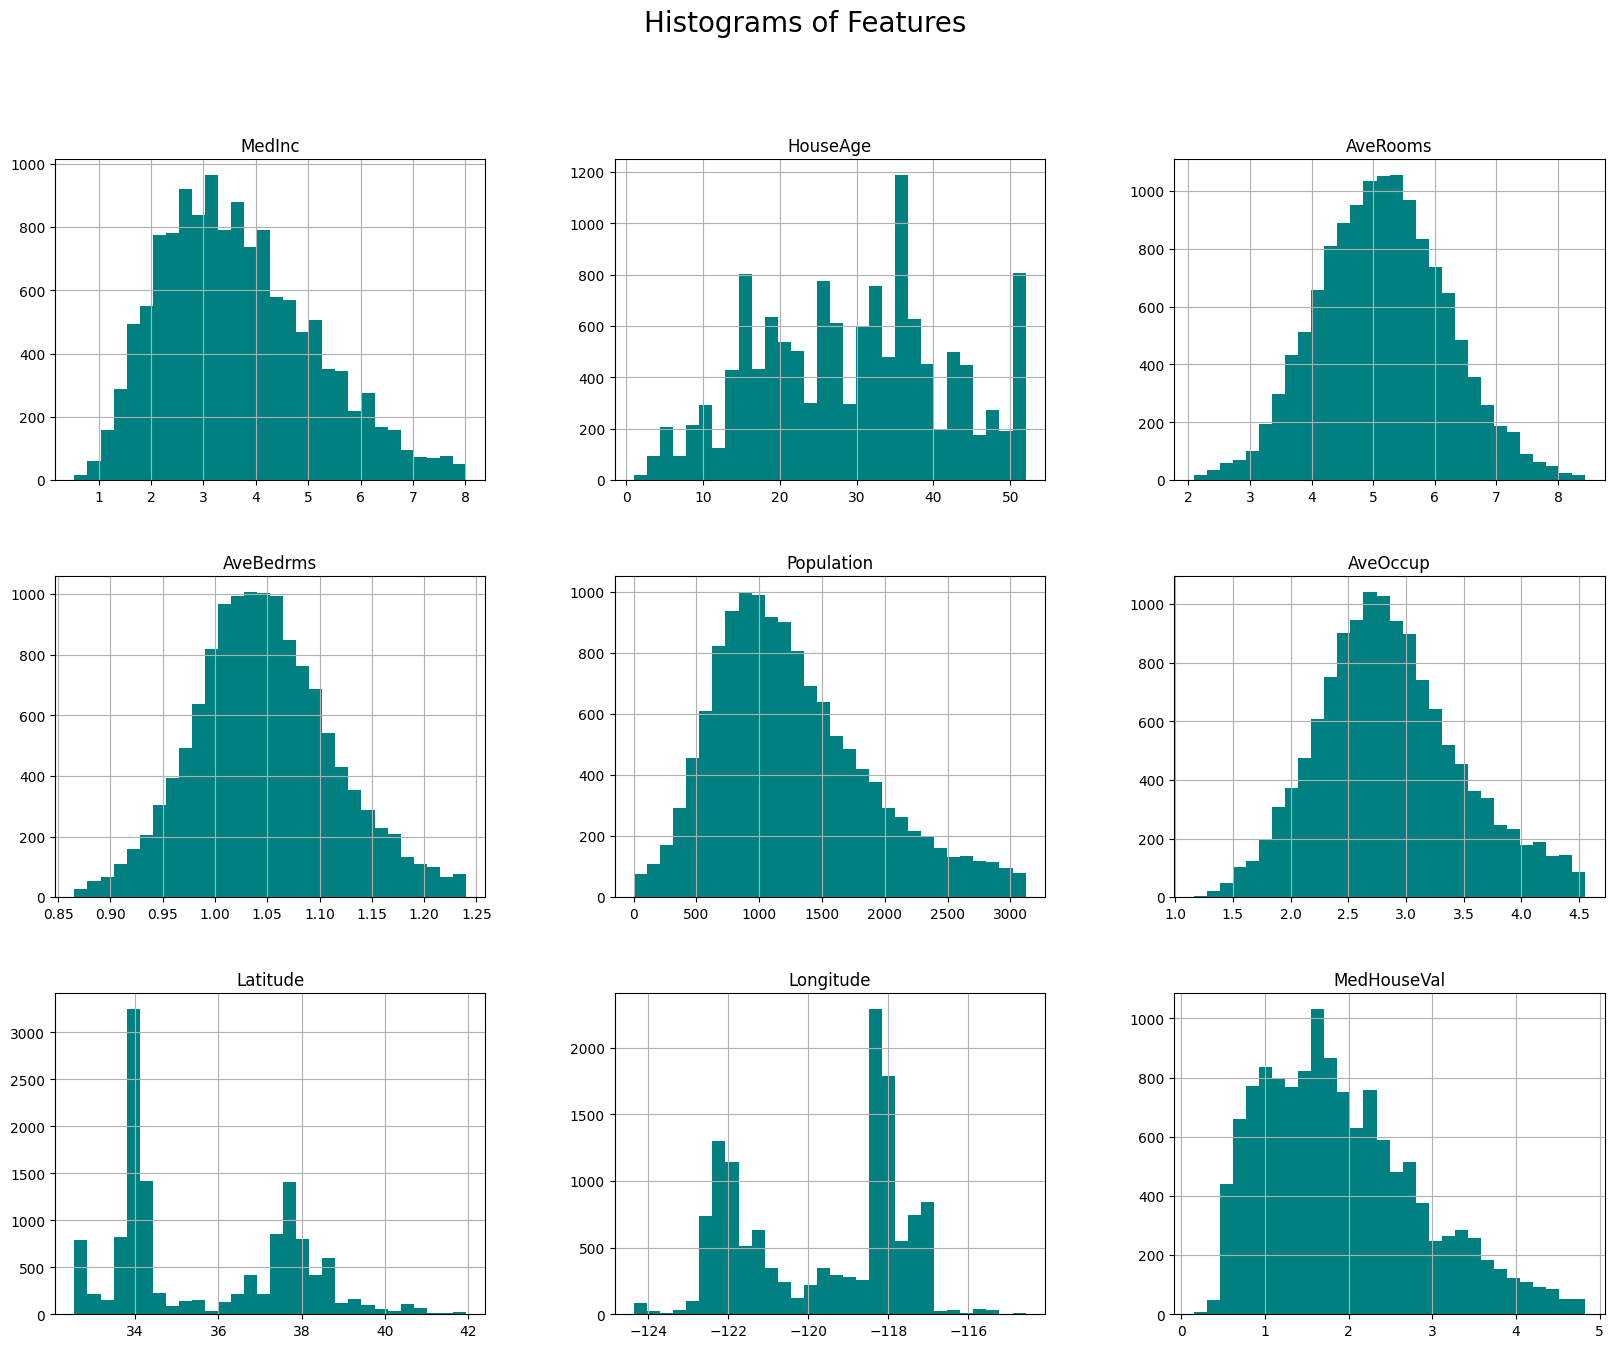

In [234]:
train_df_no_outliers.hist(bins=30, figsize=(20, 15), color='teal')
plt.suptitle('Histograms of Features', size=20)
plt.show()

In [235]:
# Feature Engineering
# Creating new features
train_df_no_outliers.loc[:, 'Rooms_per_Bedroom'] = train_df_no_outliers['AveRooms'] / train_df_no_outliers['AveBedrms']
train_df_no_outliers.loc[:, 'People_per_Household'] = train_df_no_outliers['Population'] / train_df_no_outliers['AveOccup']

# Log transformation for skewed features
train_df_no_outliers.loc[:, 'MedInc_log'] = np.log(train_df_no_outliers['MedInc'])


In [236]:
# Scaling the features
scaler = StandardScaler()
train_df_scaled = scaler.fit_transform(train_df_no_outliers.drop('MedHouseVal', axis=1))

## Part 3 - Experiments

In [237]:
# Model Selection and Cross-Validation for Random Forest and Linear Regression

# Define the models
lr = LinearRegression()
rf = RandomForestRegressor()

# Hyperparameter tuning for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [10, 20, 30],      # Maximum depth of each tree
    'min_samples_split': [2, 5]     # Minimum number of samples required to split a node
}

# GridSearchCV for Random Forest
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(train_df_scaled, train_df_no_outliers['MedHouseVal'])

# Display best parameters and score for Random Forest
print("Best parameters for Random Forest:", grid_rf.best_params_)
print("Best R² score for Random Forest:", grid_rf.best_score_)

# Hyperparameter tuning for Linear Regression
param_grid_lr = {
    'fit_intercept': [True, False],   # Whether to calculate the intercept
}

# GridSearchCV for Linear Regression
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='r2', n_jobs=-1)
grid_lr.fit(train_df_scaled, train_df_no_outliers['MedHouseVal'])

# Display best parameters and score for Linear Regression
print("Best parameters for Linear Regression:", grid_lr.best_params_)
print("Best R² score for Linear Regression:", grid_lr.best_score_)

Best parameters for Random Forest: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
Best R² score for Random Forest: 0.770036608799031
Best parameters for Linear Regression: {'fit_intercept': True}
Best R² score for Linear Regression: 0.6428479019911115


## Part 4 - Training 

In [238]:
# Retrain Best Model and Predict on Test Set
# Choose the better model based on R² scores or other criteria
best_rf = grid_rf.best_estimator_  # Best Random Forest Model
best_lr = grid_lr.best_estimator_  # Best Linear Regression Model

# Choosing the best model based on R² score
if grid_rf.best_score_ > grid_lr.best_score_:
    best_model = best_rf
else:
    best_model = best_lr
    
best_model.fit(train_df_scaled, train_df_no_outliers['MedHouseVal'])

RandomForestRegressor(max_depth=30, n_estimators=200)

## Part 5 - Apply on test and show model performance estimation

In [239]:
# Apply feature engineering on test data
test_df['Rooms_per_Bedroom'] = test_df['AveRooms'] / test_df['AveBedrms']
test_df['People_per_Household'] = test_df['Population'] / test_df['AveOccup']
test_df['MedInc_log'] = np.log(test_df['MedInc'])

# Scaling the test data
test_df_scaled = scaler.transform(test_df.drop('MedHouseVal', axis=1))

In [240]:
# Make predictions on the test data
predictions = best_model.predict(test_df_scaled)

# Evaluate the model's performance on the test set
actual_prices = test_df['MedHouseVal']

# Calculate the performance metrics
mse = mean_squared_error(actual_prices, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_prices, predictions)
r2 = r2_score(actual_prices, predictions)

# Display the evaluation results
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² score: {r2}")

Mean Squared Error (MSE): 0.3117630342790937
Root Mean Squared Error (RMSE): 0.5583574431124687
Mean Absolute Error (MAE): 0.36995575322517565
R² score: 0.7701935561753614


In [241]:
# Create a DataFrame to compare actual values and predictions
comparison_df = pd.DataFrame({
    'Actual Price': test_df['MedHouseVal'],
    'Predicted Price': predictions
})

# Display the first few rows of the comparison DataFrame
print(comparison_df.head())

# Save the comparison to a CSV file if needed
comparison_df.to_csv('actual_vs_predicted_prices.csv', index=True, index_label='Index')

   Actual Price  Predicted Price
0         3.852         3.321930
1         2.457         2.198535
2         2.013         2.529380
3         1.052         1.157790
4         1.078         1.037500
